# Cyclicity Visualization Notebook
## Positive Control vs Morph2Rep

This notebook rebuilds the key inputs needed for the poster visualizations and then makes **all candidate plots** without commenting them out.

### Outputs included
1. **1×3 heatmaps of `p_state`**
2. **1×3 heatmaps of `z_signal`**
3. **1×3 line plots of `z_signal`** with faint individual trajectories + bold mean + SEM
4. **1×3 line plots of `p_state`** with faint individual trajectories + bold mean + SEM

### Cohorts shown
- **Positive Control**
- **Morph2Rep — Vehicle Rep1**
- **Morph2Rep — 25 mg Rep2**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import pywt
import time

from datetime import datetime
from scipy.signal import cwt, morlet2
from scipy.stats import mannwhitneyu, norm, wilcoxon
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score

plt.rcParams["figure.dpi"] = 160
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
np.set_printoptions(precision=4, suppress=True)

## 1. Paths and top-level config

Update these only if needed.

In [2]:
# -----------------------------
# Positive control input
# -----------------------------
PATH_POSITIVE_CONTROL = "Mouse_Data_Student_Copy.xlsx"
POS_SHEET = "Fem Act"

# -----------------------------
# Morph2Rep S3 base path
# -----------------------------
S3_BASE = "s3://jax-envision-public-data/study_1001/2025v3.3/tabular"

# -----------------------------
# Generic constants
# -----------------------------
MINUTES_PER_DAY = 1440

## 2. Positive control pipeline
This reconstructs the positive-control dataframe `dfp` from the Excel file.

In [3]:
# -----------------------------
# 2A) Load positive control data
# -----------------------------
act_wide = pd.read_excel(PATH_POSITIVE_CONTROL, sheet_name=POS_SHEET)
assert act_wide.shape == (20160, 13), f"Expected (20160,13), got {act_wide.shape}"
assert all(str(c).startswith("f") for c in act_wide.columns), "Expected columns f1..f13"

act = act_wide.copy()
act["minute"] = np.arange(len(act))
act["day"] = act["minute"] // 1440
act["minute_of_day"] = act["minute"] % 1440

act_long = (
    act.melt(
        id_vars=["minute", "day", "minute_of_day"],
        value_vars=list(act_wide.columns),
        var_name="mouse_id",
        value_name="act",
    )
    .sort_values(["mouse_id", "minute"])
    .reset_index(drop=True)
)

print("act_long shape:", act_long.shape)
act_long.head()

act_long shape: (262080, 5)


,minute,day,minute_of_day,mouse_id,act
0,0,0,0,f1,25.0
1,1,0,1,f1,26.0
2,2,0,2,f1,35.0
3,3,0,3,f1,63.0
4,4,0,4,f1,0.0


In [4]:
# -----------------------------
# 2B) QC for positive control
# -----------------------------
MINUTES_FLOOR = 600
MINUTES_CAP = 1300

qc_daily = (
    act_long.assign(present=(act_long["act"] > 0).astype(int))
    .groupby(["mouse_id", "day"])
    .agg(minutes_act_gt0=("present", "sum"))
    .reset_index()
)
qc_daily["qc_keep"] = (
    (qc_daily["minutes_act_gt0"] >= MINUTES_FLOOR)
    & (qc_daily["minutes_act_gt0"] <= MINUTES_CAP)
)

print("Positive control QC keep rate:", float(qc_daily["qc_keep"].mean()))
qc_daily.head()

Positive control QC keep rate: 1.0


,mouse_id,day,minutes_act_gt0,qc_keep
0,f1,0,866,True
1,f1,1,901,True
2,f1,2,848,True
3,f1,3,881,True
4,f1,4,907,True


In [5]:
# -----------------------------
# 2C) Positive-control wavelet features
# -----------------------------
DT = 60.0
WAVELET = "cmor1.5-1.0"
fc = pywt.central_frequency(WAVELET)

def scales_for_period_hours(period_hours: float) -> float:
    freq_hz = 1.0 / (period_hours * 3600.0)
    return fc / (freq_hz * DT)

n_scales_per_band = 24
periods_ultr = np.linspace(1.0, 3.0, n_scales_per_band)
periods_circ = np.linspace(23.0, 25.0, n_scales_per_band)

scales_ultr = np.array([scales_for_period_hours(p) for p in periods_ultr], dtype=float)
scales_circ = np.array([scales_for_period_hours(p) for p in periods_circ], dtype=float)

def wavelet_band_series_bandonly(x_14days: np.ndarray):
    x = np.asarray(x_14days, dtype=np.float32)
    coef_u, _ = pywt.cwt(x, scales_ultr, WAVELET, sampling_period=DT)
    coef_c, _ = pywt.cwt(x, scales_circ, WAVELET, sampling_period=DT)
    U_t = (np.abs(coef_u) ** 2).max(axis=0)
    C_t = (np.abs(coef_c) ** 2).max(axis=0)
    return U_t, C_t

rows = []
t0 = time.time()
mice = sorted(act_long["mouse_id"].unique())

for i, mouse_id in enumerate(mice, start=1):
    df_m = act_long[act_long["mouse_id"] == mouse_id].sort_values("minute")
    x = df_m["act"].to_numpy()
    U_t, C_t = wavelet_band_series_bandonly(x)

    for day in range(14):
        lo, hi = day * 1440, (day + 1) * 1440
        rows.append(
            (mouse_id, day, float(np.mean(U_t[lo:hi])), float(np.mean(C_t[lo:hi])))
        )

    if i % 3 == 0 or i == len(mice):
        print(f"[{i}/{len(mice)}] positive-control mice done (elapsed {time.time() - t0:.1f}s)")

feat_pc = pd.DataFrame(rows, columns=["mouse_id", "day", "U_1_3h", "C_23_25h"])
feat_pc["log_U_over_C"] = np.log((feat_pc["U_1_3h"] + 1e-12) / (feat_pc["C_23_25h"] + 1e-12))
feat_pc = feat_pc.merge(
    qc_daily[["mouse_id", "day", "minutes_act_gt0", "qc_keep"]],
    on=["mouse_id", "day"],
    how="left",
)
feat_pc_qc = feat_pc.loc[feat_pc["qc_keep"]].copy()

print("feat_pc_qc shape:", feat_pc_qc.shape)
feat_pc_qc.head()

[3/13] positive-control mice done (elapsed 11.4s)
[6/13] positive-control mice done (elapsed 22.6s)
[9/13] positive-control mice done (elapsed 34.2s)
[12/13] positive-control mice done (elapsed 45.9s)
[13/13] positive-control mice done (elapsed 49.9s)
feat_pc_qc shape: (182, 7)


,mouse_id,day,U_1_3h,C_23_25h,log_U_over_C,minutes_act_gt0,qc_keep
0,f1,0,3062.580322,60737.390625,-2.987302,866,True
1,f1,1,1725.448608,75424.320312,-3.777643,901,True
2,f1,2,2192.337402,68390.890625,-3.440271,848,True
3,f1,3,1814.376343,68450.179688,-3.630364,881,True
4,f1,4,2125.419189,80869.085938,-3.638863,907,True


In [6]:
# -----------------------------
# 2D) Positive-control robust z-scoring
# -----------------------------
def robust_z(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-12
    return (x - med) / (1.4826 * mad)

for col in ["U_1_3h", "C_23_25h", "log_U_over_C"]:
    feat_pc_qc[f"z_{col}"] = feat_pc_qc.groupby("mouse_id")[col].transform(robust_z)

feat_pc_qc.head()

,mouse_id,day,U_1_3h,C_23_25h,log_U_over_C,minutes_act_gt0,qc_keep,z_U_1_3h,z_C_23_25h,z_log_U_over_C
0,f1,0,3062.580322,60737.390625,-2.987302,866,True,1.362957,-1.385400,1.606708
1,f1,1,1725.448608,75424.320312,-3.777643,901,True,-0.653695,0.147376,-0.449503
2,f1,2,2192.337402,68390.890625,-3.440271,848,True,0.050463,-0.586656,0.428228
3,f1,3,1814.376343,68450.179688,-3.630364,881,True,-0.519575,-0.580468,-0.066332
4,f1,4,2125.419189,80869.085938,-3.638863,907,True,-0.050463,0.715610,-0.088442


In [7]:
# -----------------------------
# 2E) Per-mouse 1D GMM -> p_lowU_1d_mouse
# -----------------------------
MIN_DAYS_PER_MOUSE = 8
MIN_WEIGHT = 0.10
MIN_SEP = 0.30

def fit_gmm_1d(x, random_state=0):
    X = np.asarray(x, dtype=float).reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=random_state)
    gmm.fit(X)
    post = gmm.predict_proba(X)
    means = gmm.means_.flatten()
    vars_ = gmm.covariances_.flatten()
    weights = gmm.weights_.flatten()
    lo = int(np.argmin(means))
    hi = 1 - lo
    sep = float(np.abs(means[hi] - means[lo]) / np.sqrt(vars_[hi] + vars_[lo] + 1e-12))
    collapsed = bool((weights.min() < MIN_WEIGHT))
    return gmm, post[:, lo], means, vars_, weights, lo, sep, collapsed

dfp = feat_pc_qc.copy()
dfp["p_lowU_1d_mouse"] = np.nan
diag_rows = []

for mid, g in dfp.groupby("mouse_id"):
    x = g["z_U_1_3h"].to_numpy()
    n_days = len(x)
    ok_n = (n_days >= MIN_DAYS_PER_MOUSE) and (np.std(x) > 1e-12)
    if not ok_n:
        diag_rows.append({
            "mouse_id": mid, "n_days": n_days,
            "means_lo": np.nan, "means_hi": np.nan,
            "w_lo": np.nan, "w_hi": np.nan,
            "var_lo": np.nan, "var_hi": np.nan,
            "sep": np.nan, "collapsed": True, "ok_fit": False,
            "reason": "too_few_days_or_constant"
        })
        continue

    gmm, p_lo, means, vars_, weights, lo, sep, collapsed = fit_gmm_1d(x, random_state=0)
    dfp.loc[dfp["mouse_id"] == mid, "p_lowU_1d_mouse"] = p_lo

    hi = 1 - lo
    ok_fit = (not collapsed) and (sep >= MIN_SEP)
    diag_rows.append({
        "mouse_id": mid, "n_days": n_days,
        "means_lo": float(means[lo]), "means_hi": float(means[hi]),
        "w_lo": float(weights[lo]), "w_hi": float(weights[hi]),
        "var_lo": float(vars_[lo]), "var_hi": float(vars_[hi]),
        "sep": float(sep), "collapsed": bool(collapsed),
        "ok_fit": bool(ok_fit), "reason": "ok" if ok_fit else ("collapsed" if collapsed else "low_sep")
    })

diag_pc = pd.DataFrame(diag_rows).sort_values("mouse_id").reset_index(drop=True)
print("Positive control fraction ok_fit:", float(diag_pc["ok_fit"].mean()))
dfp.head()

Positive control fraction ok_fit: 0.9230769230769231


,mouse_id,day,U_1_3h,C_23_25h,log_U_over_C,minutes_act_gt0,qc_keep,z_U_1_3h,z_C_23_25h,z_log_U_over_C,p_lowU_1d_mouse
0,f1,0,3062.580322,60737.390625,-2.987302,866,True,1.362957,-1.385400,1.606708,2.200955e-13
1,f1,1,1725.448608,75424.320312,-3.777643,901,True,-0.653695,0.147376,-0.449503,7.750443e-01
2,f1,2,2192.337402,68390.890625,-3.440271,848,True,0.050463,-0.586656,0.428228,1.223243e-02
3,f1,3,1814.376343,68450.179688,-3.630364,881,True,-0.519575,-0.580468,-0.066332,6.403671e-01
4,f1,4,2125.419189,80869.085938,-3.638863,907,True,-0.050463,0.715610,-0.088442,3.709070e-02


## 3. Morph2Rep pipeline
This reconstructs `feat_qc` and `p_lowU` from the S3 parquet data.

In [8]:
# -----------------------------
# 3A) Morph2Rep config
# -----------------------------
LOCO_STATE_NAME = "animal_bouts.locomotion"

THR_MINUTES = 60
THR_RATIO = 0.30
MIN_QC_DAYS_MORPH = 8

U_BAND_HOURS = (1, 3)
C_BAND_HOURS = (23, 25)
PERIODS_MINUTES = np.logspace(np.log10(60), np.log10(39 * 60), 50)

Q_CLIP = 0.995
Q_CLIP_FALLBACK = 5.0

REPLICATE_META = {
    "Rep1": {
        "analysis_start": "2025-01-07",
        "analysis_end": "2025-01-22",
        "n_days": 16,
        "valid_days": (2, 16),
        "dose_1": datetime(2025, 1, 14, 6, 0),
        "dose_2": datetime(2025, 1, 17, 17, 0),
        "cage_change": datetime(2025, 1, 15, 12, 0),
    },
    "Rep2": {
        "analysis_start": "2025-01-22",
        "analysis_end": "2025-02-04",
        "n_days": 14,
        "valid_days": (2, 14),
        "dose_1": datetime(2025, 1, 28, 17, 0),
        "dose_2": datetime(2025, 1, 31, 6, 0),
        "cage_change": datetime(2025, 1, 29, 12, 0),
    },
}

GROUP_CAGES = {
    "vehicle": {"Rep1": [4918, 4922, 4923], "Rep2": [4928, 4929, 4934]},
    "dose5":   {"Rep1": [4917, 4921, 4925], "Rep2": [4927, 4931, 4932]},
    "dose25":  {"Rep1": [4919, 4920, 4924], "Rep2": [4926, 4930, 4933]},
}

GROUPS = {}
for group_name, rep_map in GROUP_CAGES.items():
    GROUPS[group_name] = {}
    for rep_name, cages in rep_map.items():
        cfg = dict(REPLICATE_META[rep_name])
        cfg["cages"] = list(cages)
        GROUPS[group_name][rep_name] = cfg

for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        start_date = pd.to_datetime(cfg["analysis_start"]).date()
        cfg["dose_1_day"] = (cfg["dose_1"].date() - start_date).days + 1
        cfg["dose_2_day"] = (cfg["dose_2"].date() - start_date).days + 1
        cfg["cage_change_day"] = (cfg["cage_change"].date() - start_date).days + 1
        cfg["baseline_days"] = (cfg["valid_days"][0], cfg["dose_1_day"] - 1)
        cfg["event_days"] = {cfg["dose_1_day"], cfg["cage_change_day"], cfg["dose_2_day"]}
        cfg["event_and_next"] = cfg["event_days"] | {d + 1 for d in cfg["event_days"] if (d + 1) <= cfg["n_days"]}

print("Morph2Rep configuration ready.")

Morph2Rep configuration ready.


In [9]:
# -----------------------------
# 3B) Morph2Rep helpers
# -----------------------------
COV_COLS = ["animal_id", "start_time", "end_time"]
LOCO_COLS = ["animal_id", "start_time", "end_time", "state_name"]

def make_duckdb_conn():
    conn = duckdb.connect()
    conn.execute("INSTALL httpfs; LOAD httpfs;")
    conn.execute("SET s3_region='us-east-1';")
    return conn

def load_parquet_s3(conn, cage_id, start_date, end_date, table_name, columns=None, where=None):
    dates = pd.date_range(start_date, end_date, freq="D")
    out = []
    cols_sql = "*" if (not columns) else ", ".join(columns)
    where_sql = "" if (not where) else f" WHERE {where}"
    for d in dates:
        date_str = d.strftime("%Y-%m-%d")
        path = f"{S3_BASE}/cage_id={cage_id}/date={date_str}/{table_name}"
        try:
            df = conn.execute(f"SELECT {cols_sql} FROM read_parquet('{path}'){where_sql}").fetchdf()
            if df.empty:
                continue
            df["cage_id"] = cage_id
            df["date"] = date_str
            out.append(df)
        except Exception:
            continue
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

def _ensure_end_time(df):
    df = df.copy()
    for cand in ["end_time", "stop_time"]:
        if cand in df.columns:
            df["end_time"] = pd.to_datetime(df[cand])
            break
    if "end_time" not in df.columns or df["end_time"].isna().all():
        if "duration_seconds" in df.columns:
            df["end_time"] = pd.to_datetime(df["start_time"]) + pd.to_timedelta(df["duration_seconds"], unit="s")
        else:
            raise ValueError("Need bout end times.")
    df["start_time"] = pd.to_datetime(df["start_time"])
    return df

def compute_minutes_with_any_bout(df_bouts, analysis_start, n_days, anchor_hour=0):
    start_time = pd.to_datetime(f"{analysis_start} {anchor_hour:02d}:00:00")
    n_minutes = int(n_days * MINUTES_PER_DAY)
    end_time = start_time + pd.Timedelta(minutes=n_minutes)

    df = _ensure_end_time(df_bouts)
    df = df[(df["end_time"] > start_time) & (df["start_time"] < end_time)].copy()
    if df.empty:
        return pd.DataFrame(columns=["animal_id", "day", "minutes_with_any_bout"])

    s = (df["start_time"].clip(lower=start_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    e = (df["end_time"].clip(upper=end_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    start_bin = np.clip(np.floor(s).astype(np.int32), 0, n_minutes)
    end_bin = np.clip(np.ceil(e).astype(np.int32), 0, n_minutes)

    valid = end_bin > start_bin
    if not np.any(valid):
        return pd.DataFrame(columns=["animal_id", "day", "minutes_with_any_bout"])

    df2 = pd.DataFrame({
        "animal_id": df.loc[valid, "animal_id"].astype(int).to_numpy(),
        "start_bin": start_bin[valid],
        "end_bin": end_bin[valid],
    })

    pieces = []
    for aid, g in df2.groupby("animal_id", sort=False):
        for s0, e0 in g[["start_bin", "end_bin"]].to_numpy():
            d_start = int(s0) // MINUTES_PER_DAY + 1
            d_end = (int(e0) - 1) // MINUTES_PER_DAY + 1
            for day in range(d_start, d_end + 1):
                day0 = (day - 1) * MINUTES_PER_DAY
                ls = max(int(s0), day0) - day0
                le = min(int(e0), day0 + MINUTES_PER_DAY) - day0
                if le > ls:
                    pieces.append((int(aid), int(day), int(ls), int(le)))

    if not pieces:
        return pd.DataFrame(columns=["animal_id", "day", "minutes_with_any_bout"])

    tmp = pd.DataFrame(pieces, columns=["animal_id", "day", "ls", "le"])
    results = []
    for (aid, day), gg in tmp.groupby(["animal_id", "day"], sort=False):
        intervals = gg[["ls", "le"]].to_numpy()
        intervals = intervals[np.argsort(intervals[:, 0])]
        covered = 0
        cur_s, cur_e = intervals[0]
        for s2, e2 in intervals[1:]:
            if s2 <= cur_e:
                cur_e = max(cur_e, e2)
            else:
                covered += (cur_e - cur_s)
                cur_s, cur_e = s2, e2
        covered += (cur_e - cur_s)
        results.append((int(aid), int(day), int(covered)))

    return pd.DataFrame(results, columns=["animal_id", "day", "minutes_with_any_bout"])

def bouts_to_minute_counts(loco_bouts_df, analysis_start, n_days, anchor_hour=0, binary=False):
    start_time = pd.to_datetime(f"{analysis_start} {anchor_hour:02d}:00:00")
    n_minutes = int(n_days * MINUTES_PER_DAY)
    end_time = start_time + pd.Timedelta(minutes=n_minutes)

    if loco_bouts_df is None or len(loco_bouts_df) == 0:
        return np.zeros(n_minutes, dtype=float)

    df = _ensure_end_time(loco_bouts_df)
    df = df[(df["end_time"] > start_time) & (df["start_time"] < end_time)].copy()
    if df.empty:
        return np.zeros(n_minutes, dtype=float)

    s = (df["start_time"].clip(lower=start_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    e = (df["end_time"].clip(upper=end_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    start_bin = np.clip(np.floor(s).astype(np.int32), 0, n_minutes)
    end_bin = np.clip(np.ceil(e).astype(np.int32), 0, n_minutes)

    valid = end_bin > start_bin
    if not np.any(valid):
        return np.zeros(n_minutes, dtype=np.float32)

    diff = np.zeros(n_minutes + 1, dtype=np.int32)
    np.add.at(diff, start_bin[valid], 1)
    np.add.at(diff, end_bin[valid], -1)
    occ = np.cumsum(diff[:-1])

    return (occ > 0).astype(np.float32) if binary else occ.astype(np.float32)

def compute_wavelet_power(signal_1min, periods_minutes=None, w=5):
    x = pd.Series(signal_1min).interpolate().bfill().ffill().fillna(0).values
    if periods_minutes is None:
        periods_minutes = PERIODS_MINUTES
    periods_minutes = np.asarray(periods_minutes, dtype=float)
    scales = periods_minutes * 1.0 * w / (2 * np.pi)
    coeffs = cwt(x, morlet2, scales, w=w)
    return np.abs(coeffs) ** 2, periods_minutes

def extract_band_power_ts(power, periods_minutes, band_hours, reduce="max"):
    periods_hours = periods_minutes / 60
    mask = (periods_hours >= band_hours[0]) & (periods_hours <= band_hours[1])
    if not np.any(mask):
        return np.zeros(power.shape[1], dtype=float)
    return np.max(power[mask, :], axis=0) if reduce == "max" else np.mean(power[mask, :], axis=0)

def daily_mean_from_minute_ts(minute_ts, n_days):
    out = []
    for d in range(1, n_days + 1):
        s = (d - 1) * MINUTES_PER_DAY
        e = d * MINUTES_PER_DAY
        out.append(np.nanmean(minute_ts[s:e]) if e <= len(minute_ts) else np.nan)
    return out

def baseline_anchored_z(values, baseline_mask, eps=1e-8):
    values = np.asarray(values, dtype=float)
    baseline_mask = np.asarray(baseline_mask, dtype=bool)

    bl_vals = values[baseline_mask & np.isfinite(values)]
    if len(bl_vals) < 3:
        bl_vals = values[np.isfinite(values)]
    if len(bl_vals) < 2:
        return np.full_like(values, np.nan)

    med = np.nanmedian(bl_vals)
    mad = np.nanmedian(np.abs(bl_vals - med))
    return (values - med) / (mad + eps)

def clip_per_mouse_quantile(z_all, baseline_mask, q=0.995, fallback_clip=5.0, min_baseline=4):
    z_all = np.asarray(z_all, dtype=float)
    baseline_mask = np.asarray(baseline_mask, dtype=bool)

    z_bl = z_all[baseline_mask & np.isfinite(z_all)]
    if z_bl.size < min_baseline:
        z_bl = z_all[np.isfinite(z_all)]

    if z_bl.size < 2:
        return z_all, np.nan, 0

    thr = float(np.quantile(np.abs(z_bl), q))
    if (not np.isfinite(thr)) or thr <= 0:
        thr = float(fallback_clip)

    z_clip = np.clip(z_all, -thr, thr)
    n_clipped = int(np.sum(np.isfinite(z_all) & (np.abs(z_all) > thr)))
    return z_clip, thr, n_clipped

In [10]:
# -----------------------------
# 3C) Load Morph2Rep coverage and features
# -----------------------------
conn = make_duckdb_conn()

cov_all = []
print("Loading Morph2Rep coverage...")
for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]
        for cage_id in cfg["cages"]:
            df_cov = load_parquet_s3(
                conn,
                cage_id,
                cfg["analysis_start"],
                cfg["analysis_end"],
                "animal_bouts.parquet",
                columns=COV_COLS,
            )
            if df_cov.empty:
                continue
            cov = compute_minutes_with_any_bout(df_cov, cfg["analysis_start"], cfg["n_days"])
            cov["group"], cov["replicate"], cov["cage_id"] = group, rep, cage_id
            cov = cov[(cov["day"] >= vstart) & (cov["day"] <= vend)]
            cov_all.append(cov)

cov_df = pd.concat(cov_all, ignore_index=True)
cov_df = cov_df[cov_df["animal_id"].notna() & (cov_df["animal_id"].astype(int) != 0)].copy()
med = cov_df.groupby(["group", "replicate", "animal_id"])["minutes_with_any_bout"].transform("median")
cov_df["coverage_ratio"] = (cov_df["minutes_with_any_bout"] / med).replace([np.inf, -np.inf], np.nan).fillna(0)
cov_df["qc_keep"] = (cov_df["minutes_with_any_bout"] >= THR_MINUTES) & (cov_df["coverage_ratio"] >= THR_RATIO)

print("Morph2Rep coverage rows:", len(cov_df))
print("Morph2Rep QC keep rate:", float(cov_df["qc_keep"].mean()))

Loading Morph2Rep coverage...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Morph2Rep coverage rows: 753
Morph2Rep QC keep rate: 0.9920318725099602


In [11]:
# -----------------------------
# 3D) Extract Morph2Rep wavelet features
# -----------------------------
rows = []

print("Extracting Morph2Rep wavelet features...")
for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]
        n_days = cfg["n_days"]
        start_date = pd.to_datetime(cfg["analysis_start"])
        date_list = [(start_date + pd.Timedelta(days=i)).date() for i in range(n_days)]
        bl_start, bl_end = cfg["baseline_days"]

        for cage_id in cfg["cages"]:
            df_loco = load_parquet_s3(
                conn,
                cage_id,
                cfg["analysis_start"],
                cfg["analysis_end"],
                "animal_bouts.parquet",
                columns=LOCO_COLS,
                where=f"state_name = '{LOCO_STATE_NAME}'",
            )

            cov_animals = cov_df[
                (cov_df["group"] == group)
                & (cov_df["replicate"] == rep)
                & (cov_df["cage_id"] == cage_id)
            ]["animal_id"].dropna().astype(int).unique()

            if len(cov_animals) == 0:
                continue

            for aid in cov_animals:
                a_loco = (
                    df_loco[df_loco["animal_id"] == aid].copy()
                    if not df_loco.empty
                    else pd.DataFrame(columns=LOCO_COLS)
                )

                x_1min = bouts_to_minute_counts(a_loco, cfg["analysis_start"], n_days, binary=False)

                power, periods = compute_wavelet_power(x_1min, PERIODS_MINUTES, w=5)
                U_ts = extract_band_power_ts(power, periods, U_BAND_HOURS, reduce="max")
                C_ts = extract_band_power_ts(power, periods, C_BAND_HOURS, reduce="max")

                U_day = daily_mean_from_minute_ts(U_ts, n_days)
                C_day = daily_mean_from_minute_ts(C_ts, n_days)

                for day in range(vstart, vend + 1):
                    u = float(U_day[day - 1])
                    c = float(C_day[day - 1])
                    rows.append({
                        "group": group,
                        "replicate": rep,
                        "cage_id": int(cage_id),
                        "animal_id": int(aid),
                        "day": int(day),
                        "date": str(date_list[day - 1]),
                        "U_1_3h": u,
                        "C_23_25h": c,
                        "log_U_over_C": float(np.log((u + 1e-6) / (c + 1e-6))),
                        "is_event": int(day in cfg["event_days"]),
                        "is_event_or_next": int(day in cfg["event_and_next"]),
                        "is_baseline": int(bl_start <= day <= bl_end),
                    })

feat = pd.DataFrame(rows)
feat = feat[feat["animal_id"].notna() & (feat["animal_id"].astype(int) != 0)].copy()

merge_cols = ["group", "replicate", "cage_id", "animal_id", "day", "minutes_with_any_bout", "coverage_ratio", "qc_keep"]
feat = feat.merge(
    cov_df[merge_cols],
    on=["group", "replicate", "cage_id", "animal_id", "day"],
    how="left",
)
feat["qc_keep"] = feat["qc_keep"].fillna(False)

print("Morph2Rep feature rows:", len(feat))
feat.head()

Extracting Morph2Rep wavelet features...
Morph2Rep feature rows: 756


,group,replicate,cage_id,animal_id,day,date,U_1_3h,C_23_25h,log_U_over_C,is_event,is_event_or_next,is_baseline,minutes_with_any_bout,coverage_ratio,qc_keep
0,vehicle,Rep1,4918,9259,2,2025-01-08,101.562345,764.332279,-2.018330,0,0,1,1380.0,0.958333,True
1,vehicle,Rep1,4918,9259,3,2025-01-09,86.495025,877.984830,-2.317542,0,0,1,1440.0,1.000000,True
2,vehicle,Rep1,4918,9259,4,2025-01-10,150.844814,779.567006,-1.642487,0,0,1,1440.0,1.000000,True
3,vehicle,Rep1,4918,9259,5,2025-01-11,122.064615,870.430831,-1.964438,0,0,1,1440.0,1.000000,True
4,vehicle,Rep1,4918,9259,6,2025-01-12,189.146858,1104.961927,-1.765042,0,0,1,1440.0,1.000000,True


In [12]:
# -----------------------------
# 3E) Morph2Rep baseline-anchored z-scoring + clipping
# -----------------------------
feat_qc = feat[feat["qc_keep"]].copy()

day_counts = feat_qc.groupby(["group", "replicate", "animal_id"]).size()
keep_mice = day_counts[day_counts >= MIN_QC_DAYS_MORPH].index
feat_qc = feat_qc.set_index(["group", "replicate", "animal_id"]).loc[keep_mice].reset_index()

for col in ["U_1_3h", "C_23_25h", "log_U_over_C"]:
    z_col = f"z_{col}"
    feat_qc[z_col] = np.nan
    for (g, r, aid), grp in feat_qc.groupby(["group", "replicate", "animal_id"]):
        idx = grp.index
        bl_mask = grp["is_baseline"].values.astype(bool)
        z = baseline_anchored_z(grp[col].values, bl_mask)
        z_clip, thr, n_clipped = clip_per_mouse_quantile(
            z, bl_mask, q=Q_CLIP, fallback_clip=Q_CLIP_FALLBACK
        )
        feat_qc.loc[idx, z_col] = z_clip

feat_qc = feat_qc.dropna(subset=["z_U_1_3h"]).copy()
print("Morph2Rep rows after z-scoring/clipping:", len(feat_qc))
feat_qc.head()

Morph2Rep rows after z-scoring/clipping: 747


,group,replicate,animal_id,cage_id,day,date,U_1_3h,C_23_25h,log_U_over_C,is_event,is_event_or_next,is_baseline,minutes_with_any_bout,coverage_ratio,qc_keep,z_U_1_3h,z_C_23_25h,z_log_U_over_C
0,dose25,Rep1,9275,4919,2,2025-01-08,98.018956,1032.787649,-2.354856,0,0,1,1440.0,1.000000,True,1.468999,-0.565666,0.626285
1,dose25,Rep1,9275,4919,3,2025-01-09,137.741934,1107.526543,-2.084503,0,0,1,1440.0,1.000000,True,4.855790,-0.241200,1.480363
2,dose25,Rep1,9275,4919,4,2025-01-10,77.858197,1218.644555,-2.750605,0,0,1,1380.0,0.958333,True,-0.293987,0.241200,-0.626285
3,dose25,Rep1,9275,4919,5,2025-01-11,84.582011,1517.273946,-2.886949,0,0,1,1380.0,0.958333,True,0.293987,1.537647,-1.057820
4,dose25,Rep1,9275,4919,6,2025-01-12,74.306296,1493.476518,-3.000666,0,0,1,1440.0,1.000000,True,-0.604588,1.434334,-1.417742


In [13]:
# -----------------------------
# 3F) Morph2Rep per-mouse GMM -> p_lowU
# -----------------------------
feat_qc["p_lowU"] = np.nan
gmm_results = []

for (g, r, aid), grp in feat_qc.groupby(["group", "replicate", "animal_id"]):
    idx = grp.index
    x = grp["z_U_1_3h"].values.reshape(-1, 1)
    if len(x) < 6:
        gmm_results.append({
            "group": g,
            "replicate": r,
            "animal_id": aid,
            "n_days": len(x),
            "status": "too_few",
            "sep": np.nan
        })
        continue
    try:
        gmm = GaussianMixture(
            n_components=2,
            covariance_type="full",
            reg_covar=1e-4,
            random_state=SEED,
            n_init=5
        )
        gmm.fit(x)
        post = gmm.predict_proba(x)
        means = gmm.means_.flatten()
        low_comp = int(np.argmin(means))
        feat_qc.loc[idx, "p_lowU"] = post[:, low_comp]
        sep = abs(means[0] - means[1])
        gmm_results.append({
            "group": g,
            "replicate": r,
            "animal_id": aid,
            "n_days": len(x),
            "status": "ok",
            "sep": sep,
            "m0": means[0],
            "m1": means[1],
        })
    except Exception:
        gmm_results.append({
            "group": g,
            "replicate": r,
            "animal_id": aid,
            "n_days": len(x),
            "status": "error",
            "sep": np.nan
        })

gmm_df = pd.DataFrame(gmm_results)
feat_qc = feat_qc.dropna(subset=["p_lowU"]).copy()

print("Morph2Rep GMM successes:", int((gmm_df["status"] == "ok").sum()), "/", len(gmm_df))
feat_qc.head()

Morph2Rep GMM successes: 54 / 54


,group,replicate,animal_id,cage_id,day,date,U_1_3h,C_23_25h,log_U_over_C,is_event,is_event_or_next,is_baseline,minutes_with_any_bout,coverage_ratio,qc_keep,z_U_1_3h,z_C_23_25h,z_log_U_over_C,p_lowU
0,dose25,Rep1,9275,4919,2,2025-01-08,98.018956,1032.787649,-2.354856,0,0,1,1440.0,1.000000,True,1.468999,-0.565666,0.626285,0.280186
1,dose25,Rep1,9275,4919,3,2025-01-09,137.741934,1107.526543,-2.084503,0,0,1,1440.0,1.000000,True,4.855790,-0.241200,1.480363,0.000013
2,dose25,Rep1,9275,4919,4,2025-01-10,77.858197,1218.644555,-2.750605,0,0,1,1380.0,0.958333,True,-0.293987,0.241200,-0.626285,0.989062
3,dose25,Rep1,9275,4919,5,2025-01-11,84.582011,1517.273946,-2.886949,0,0,1,1380.0,0.958333,True,0.293987,1.537647,-1.057820,0.935981
4,dose25,Rep1,9275,4919,6,2025-01-12,74.306296,1493.476518,-3.000666,0,0,1,1440.0,1.000000,True,-0.604588,1.434334,-1.417742,0.995803


## 4. Build a common plotting dataframe

In [14]:
def prep_positive_control_plot(dfp):
    out = dfp.copy().rename(columns={
        "mouse_id": "mouse",
        "p_lowU_1d_mouse": "p_state",
        "z_U_1_3h": "z_signal",
    })
    out = out[["mouse", "day", "p_state", "z_signal"]].copy()
    out["cohort"] = "Positive Control"
    return out

def prep_morph2rep_plot(feat_qc, group, replicate, cohort_name):
    sub = feat_qc[(feat_qc["group"] == group) & (feat_qc["replicate"] == replicate)].copy()
    out = sub.rename(columns={
        "animal_id": "mouse",
        "p_lowU": "p_state",
        "z_U_1_3h": "z_signal",
    })
    out = out[["mouse", "day", "p_state", "z_signal"]].copy()
    out["cohort"] = cohort_name
    return out

plot_df = pd.concat([
    prep_positive_control_plot(dfp),
    prep_morph2rep_plot(feat_qc, "vehicle", "Rep1", "Vehicle Rep1"),
    prep_morph2rep_plot(feat_qc, "dose25", "Rep2", "25 mg Rep2"),
], ignore_index=True)

plot_df["mouse"] = plot_df["mouse"].astype(str)
print(plot_df["cohort"].value_counts())
plot_df.head()

cohort
Positive Control    182
Vehicle Rep1        135
25 mg Rep2          117
Name: count, dtype: int64


,mouse,day,p_state,z_signal,cohort
0,f1,0,2.200955e-13,1.362957,Positive Control
1,f1,1,7.750443e-01,-0.653695,Positive Control
2,f1,2,1.223243e-02,0.050463,Positive Control
3,f1,3,6.403671e-01,-0.519575,Positive Control
4,f1,4,3.709070e-02,-0.050463,Positive Control


## 5. Plotting helpers

In [18]:
def order_mice_for_heatmap(sub: pd.DataFrame, value_col: str) -> list:
    piv = sub.pivot_table(index="mouse", columns="day", values=value_col, aggfunc="mean")

    mouse_ids = piv.index.astype(str)

    if value_col == "p_state":
        peak_day = piv.idxmax(axis=1)
        mean_val = piv.mean(axis=1)
        order_df = pd.DataFrame({
            "mouse_id": mouse_ids,
            "primary": peak_day.to_numpy(),
            "secondary": (-mean_val).to_numpy(),
        })
    else:
        trough_day = piv.idxmin(axis=1)
        mean_val = piv.mean(axis=1)
        order_df = pd.DataFrame({
            "mouse_id": mouse_ids,
            "primary": trough_day.to_numpy(),
            "secondary": mean_val.to_numpy(),
        })

    order_df["primary"] = pd.to_numeric(order_df["primary"], errors="coerce").fillna(1e9)
    order_df["secondary"] = pd.to_numeric(order_df["secondary"], errors="coerce")
    order_df["secondary"] = order_df["secondary"].fillna(order_df["secondary"].mean() if order_df["secondary"].notna().any() else 0)

    order_df = order_df.sort_values(
        ["primary", "secondary", "mouse_id"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    return order_df["mouse_id"].tolist()

def summarize_daywise(sub: pd.DataFrame, value_col: str) -> pd.DataFrame:
    return (
        sub.groupby("day")[value_col]
        .agg(mean="mean", sem="sem", n="count")
        .reset_index()
        .sort_values("day")
    )

def plot_1x3_heatmaps(
    plot_df: pd.DataFrame,
    value_col: str = "p_state",
    cmap: str = "RdYlBu_r",
    figsize=(16, 4.8),
    title=None,
    show_pc_guides: bool = True,
    pc_guides=(1, 5, 9, 13),
    morph_event_lines=None,
    vmin=None,
    vmax=None,
):
    cohorts = ["Positive Control", "Vehicle Rep1", "25 mg Rep2"]

    if vmin is None or vmax is None:
        if value_col == "p_state":
            vmin, vmax = 0.0, 1.0
        else:
            vals = plot_df[value_col].to_numpy(dtype=float)
            finite_vals = vals[np.isfinite(vals)]
            lim = np.nanpercentile(np.abs(finite_vals), 95) if finite_vals.size else 1.0
            lim = max(lim, 1.0)
            vmin, vmax = -lim, lim

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=False)
    im = None

    for ax, cohort in zip(axes, cohorts):
        sub = plot_df[plot_df["cohort"] == cohort].copy()
        mouse_order = order_mice_for_heatmap(sub, value_col=value_col)

        heat = (
            sub.pivot_table(index="mouse", columns="day", values=value_col, aggfunc="mean")
            .reindex(mouse_order)
        )
        all_days = sorted(sub["day"].dropna().unique())
        heat = heat.reindex(columns=all_days)

        im = ax.imshow(
            heat.values,
            aspect="auto",
            interpolation="nearest",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(cohort, fontweight="bold")
        ax.set_xlabel("Day")
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels([str(int(d)) for d in heat.columns], fontsize=9)
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels(list(heat.index), fontsize=7)
        ax.set_ylabel("Mouse")

        day_to_idx = {d: i for i, d in enumerate(heat.columns)}

        if show_pc_guides and cohort == "Positive Control":
            for d in pc_guides:
                if d in day_to_idx:
                    ax.axvline(day_to_idx[d], color="black", linestyle="--", linewidth=1.0, alpha=0.35)

        if morph_event_lines and cohort in morph_event_lines:
            for d in morph_event_lines[cohort]:
                if d in day_to_idx:
                    ax.axvline(day_to_idx[d], color="black", linestyle=":", linewidth=1.2, alpha=0.45)

    if title is None:
        title = "Cyclicity comparison across cohorts"

    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.02)
    fig.subplots_adjust(right=0.92, wspace=0.28)
    cbar_ax = fig.add_axes([0.94, 0.17, 0.015, 0.68])
    fig.colorbar(im, cax=cbar_ax, label=("p_state" if value_col == "p_state" else "z_U_1_3h"))
    plt.show()

def plot_1x3_lines(
    plot_df: pd.DataFrame,
    value_col: str = "z_signal",
    figsize=(16, 4.8),
    title=None,
    show_pc_guides: bool = True,
    pc_guides=(1, 5, 9, 13),
    morph_event_lines=None,
    cohort_colors=None,
    alpha_individual=0.25,
    lw_individual=1.0,
    lw_mean=3.0,
    marker_mean="o",
    ylims=None,
):
    cohorts = ["Positive Control", "Vehicle Rep1", "25 mg Rep2"]

    if cohort_colors is None:
        cohort_colors = {
            "Positive Control": "#3B5BDB",
            "Vehicle Rep1": "#2B8A3E",
            "25 mg Rep2": "#C92A2A",
        }

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True, constrained_layout=False)

    if ylims is None:
        vals = plot_df[value_col].to_numpy(dtype=float)
        finite_vals = vals[np.isfinite(vals)]
        lo = np.nanpercentile(finite_vals, 2) if finite_vals.size else -1
        hi = np.nanpercentile(finite_vals, 98) if finite_vals.size else 1
        pad = 0.15 * max(hi - lo, 1e-6)
        ylims = (lo - pad, hi + pad)

    for ax, cohort in zip(axes, cohorts):
        sub = plot_df[plot_df["cohort"] == cohort].copy()
        color = cohort_colors[cohort]

        for mouse, g in sub.groupby("mouse"):
            g = g.sort_values("day")
            ax.plot(g["day"], g[value_col], color=color, alpha=alpha_individual, linewidth=lw_individual)

        summ = summarize_daywise(sub, value_col=value_col)
        ax.plot(
            summ["day"], summ["mean"],
            color=color, linewidth=lw_mean, marker=marker_mean, markersize=5
        )
        ax.fill_between(
            summ["day"].to_numpy(dtype=float),
            (summ["mean"] - summ["sem"]).to_numpy(dtype=float),
            (summ["mean"] + summ["sem"]).to_numpy(dtype=float),
            color=color, alpha=0.18
        )

        if show_pc_guides and cohort == "Positive Control":
            for d in pc_guides:
                ax.axvline(d, color="black", linestyle="--", linewidth=1.0, alpha=0.35)

        if morph_event_lines and cohort in morph_event_lines:
            for d in morph_event_lines[cohort]:
                ax.axvline(d, color="black", linestyle=":", linewidth=1.2, alpha=0.45)

        ax.set_title(cohort, fontweight="bold")
        ax.set_xlabel("Day")
        ax.set_ylim(*ylims)
        ax.grid(True, axis="y", alpha=0.18)

    axes[0].set_ylabel("p_state" if value_col == "p_state" else "z_U_1_3h")

    if title is None:
        title = "Cyclicity comparison across cohorts"

    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.02)
    fig.subplots_adjust(wspace=0.22)
    plt.show()

## 6. Optional event lines for Morph2Rep panels
Set to `None` if you want cleaner poster figures.

In [19]:
morph_event_lines = {
    "Vehicle Rep1": [8, 9, 11],
    "25 mg Rep2": [7, 8, 10],
}

# To disable event lines in the figures below, set:
# morph_event_lines = None

## 7. Make all candidate figures
Nothing is commented out here.

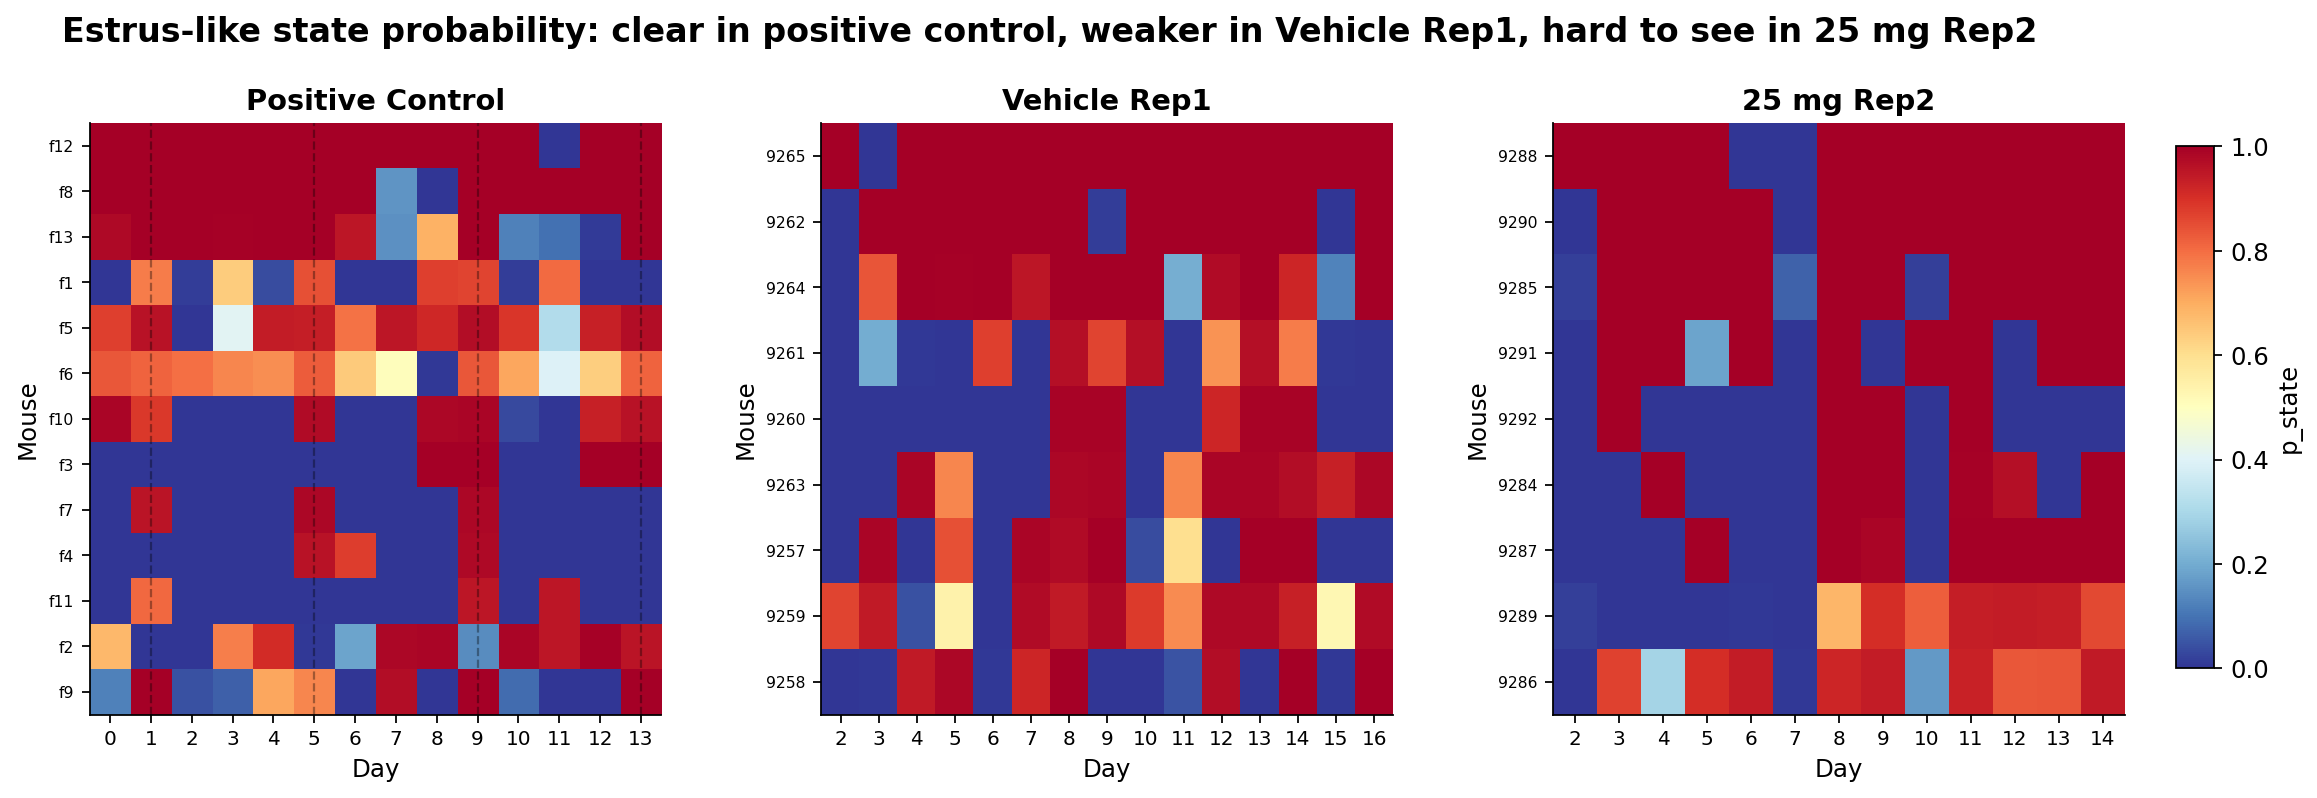

In [20]:
plot_1x3_heatmaps(
    plot_df,
    value_col="p_state",
    cmap="RdYlBu_r",
    title="Estrus-like state probability: clear in positive control, weaker in Vehicle Rep1, hard to see in 25 mg Rep2",
    show_pc_guides=True,
    pc_guides=(1, 5, 9, 13),
    morph_event_lines=None,
)

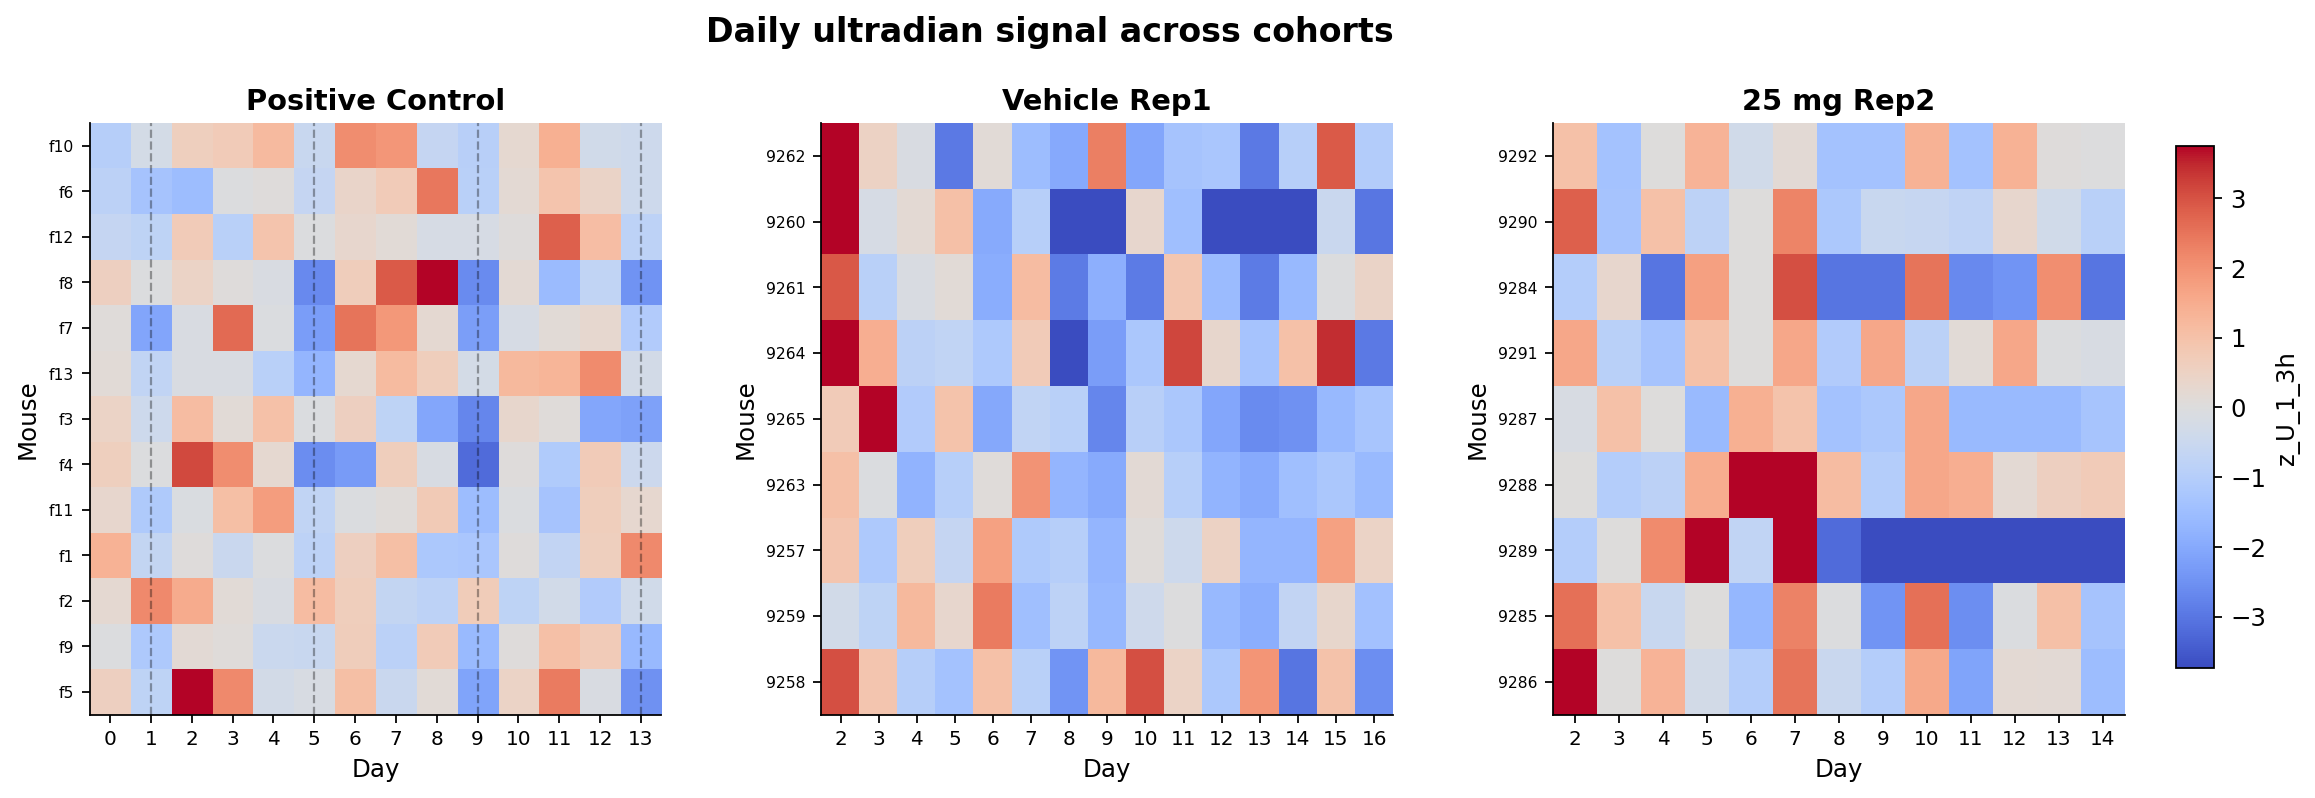

In [21]:
plot_1x3_heatmaps(
    plot_df,
    value_col="z_signal",
    cmap="coolwarm",
    title="Daily ultradian signal across cohorts",
    show_pc_guides=True,
    pc_guides=(1, 5, 9, 13),
    morph_event_lines=None,
)

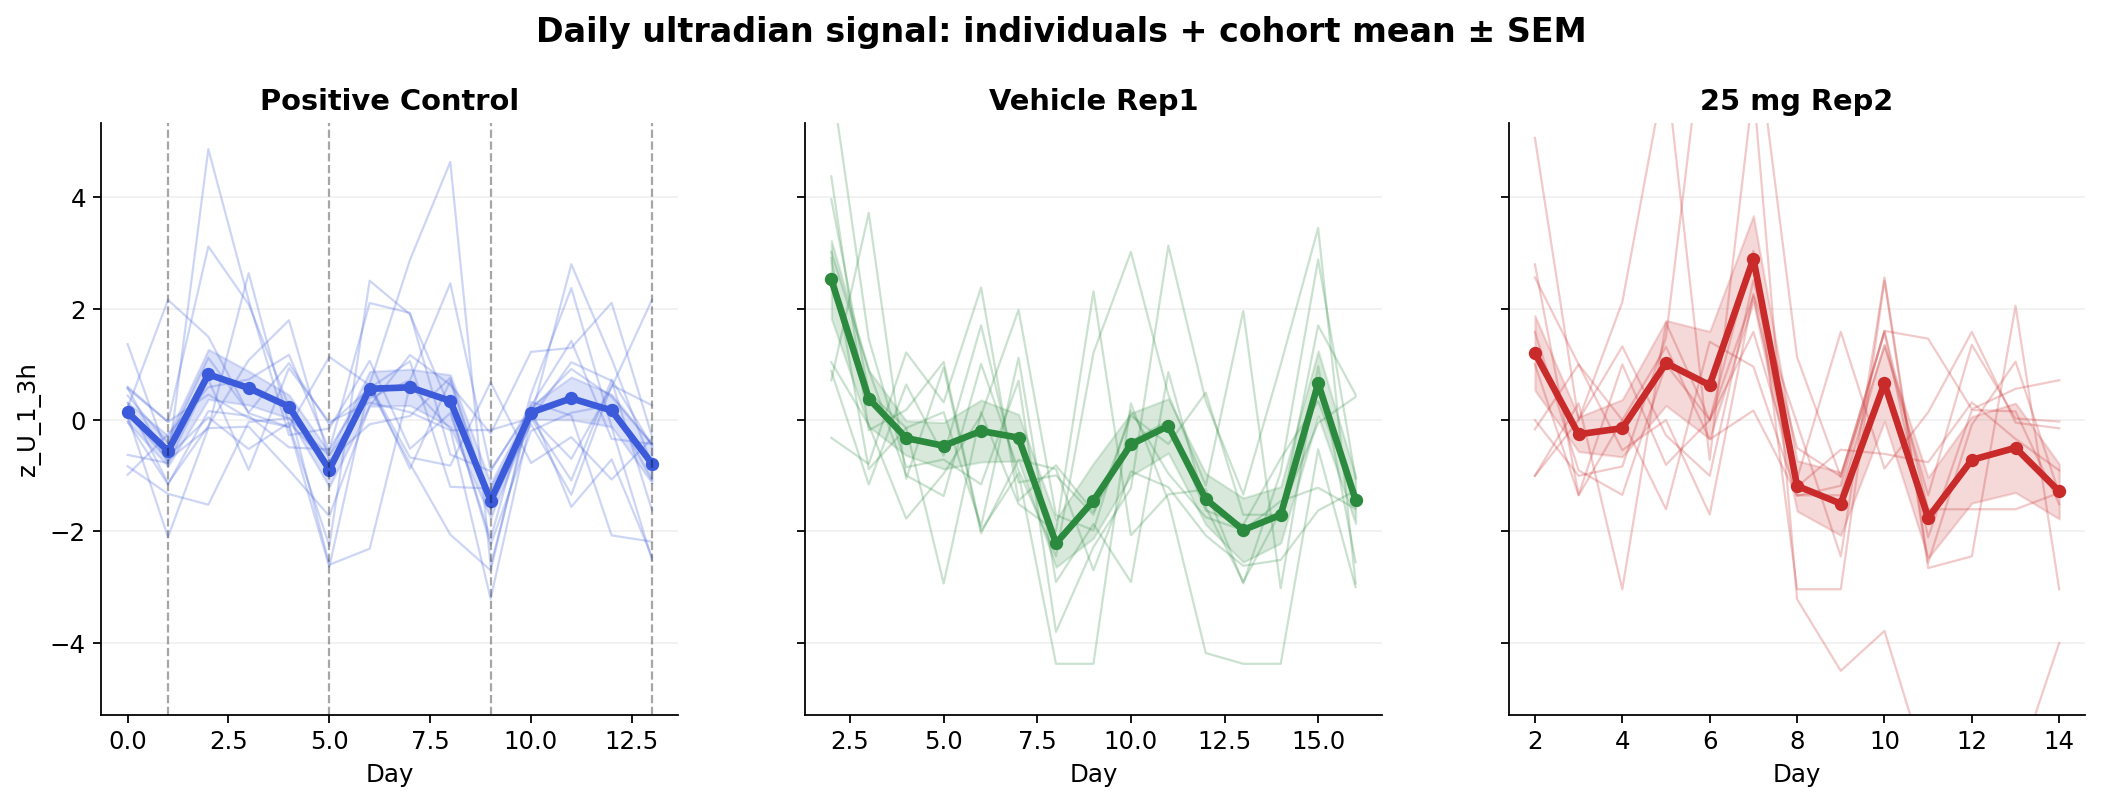

In [22]:
plot_1x3_lines(
    plot_df,
    value_col="z_signal",
    title="Daily ultradian signal: individuals + cohort mean ± SEM",
    show_pc_guides=True,
    pc_guides=(1, 5, 9, 13),
    morph_event_lines=None,
)

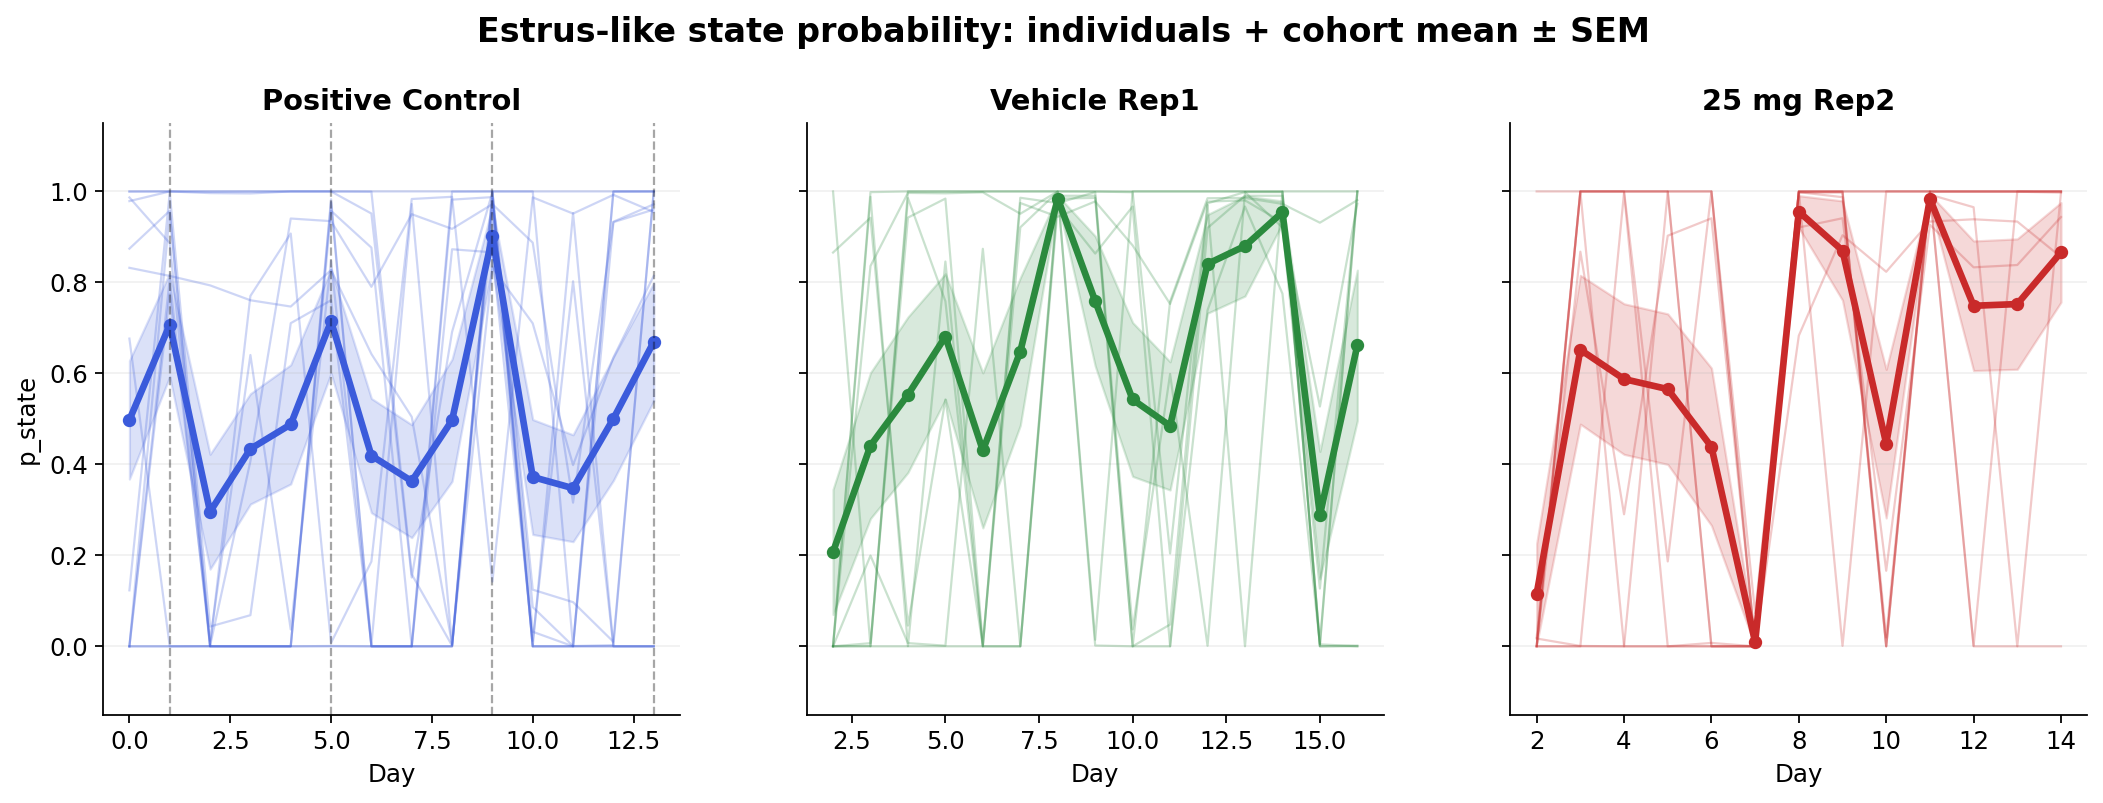

In [23]:
plot_1x3_lines(
    plot_df,
    value_col="p_state",
    title="Estrus-like state probability: individuals + cohort mean ± SEM",
    show_pc_guides=True,
    pc_guides=(1, 5, 9, 13),
    morph_event_lines=None,
)

Replicate: Rep1
Using event: dose_1 -> 2025-01-14 06:00:00
Baseline day: 4
Matched baseline center: 2025-01-10 06:00:00
Representative cages: {'vehicle': 4918, 'dose5': 4917, 'dose25': 4919}


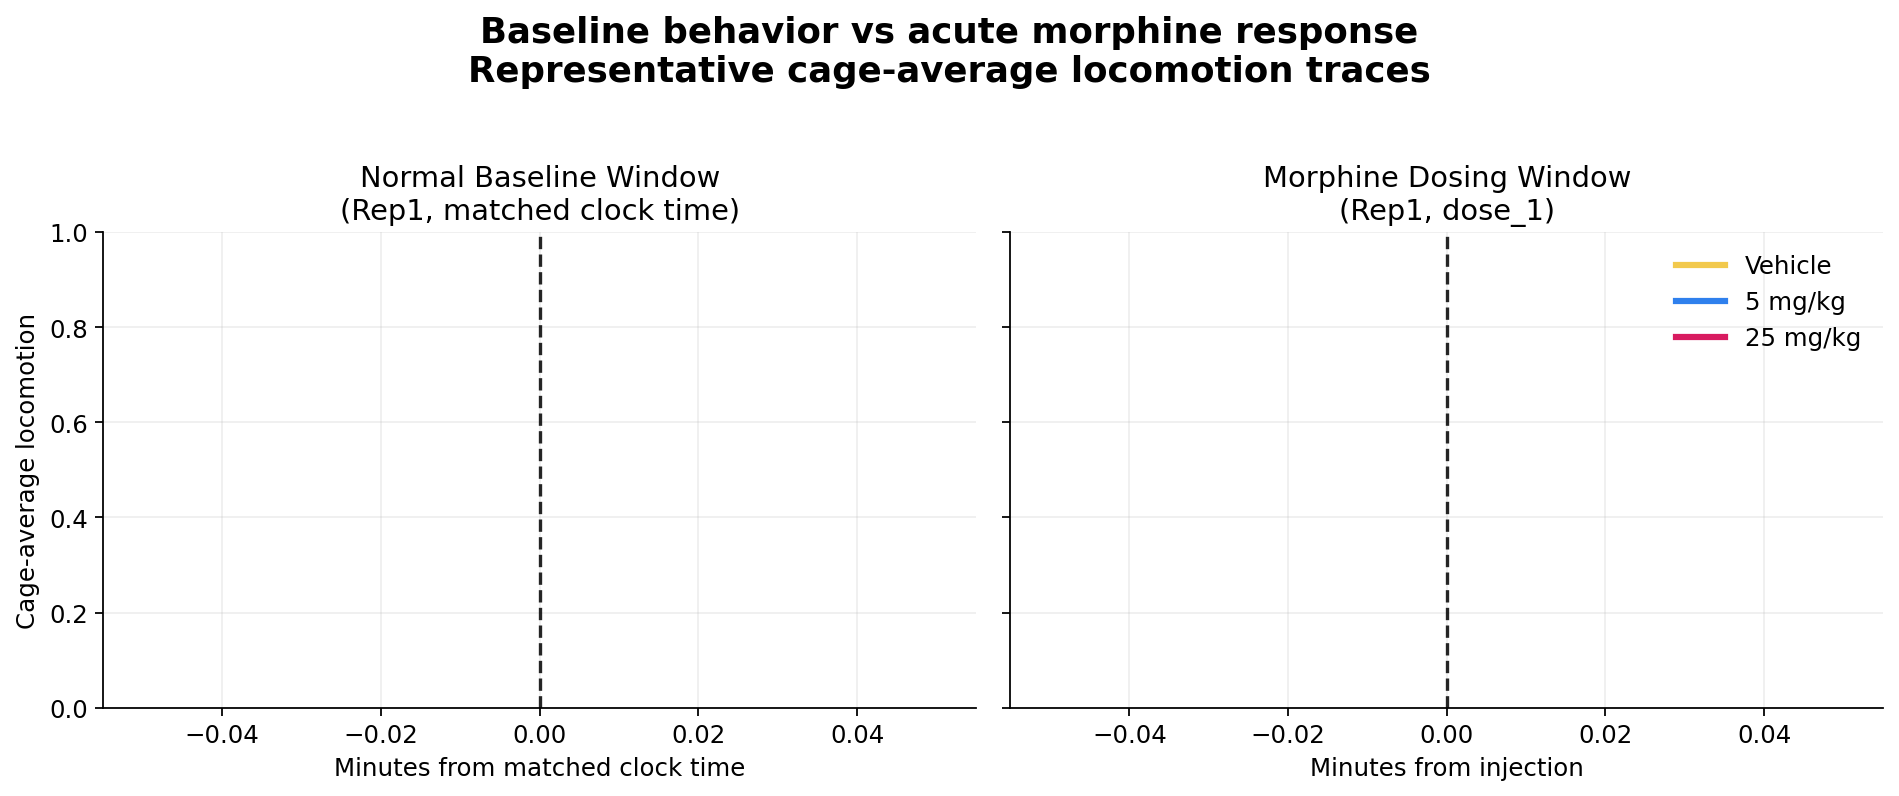

In [26]:
# =============================================================================
# Poster figure: baseline vs morphine using continuous cage-average locomotion
# One line per treatment group, averaged across the 3 mice in one representative cage
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# USER SETTINGS
# ---------------------------------------------------------------------
PLOT_REP = "Rep1"          # "Rep1" or "Rep2"
USE_DOSE = "dose_1"        # "dose_1" or "dose_2"

# Representative cage per treatment group
REP_CAGES = {
    "vehicle": GROUPS["vehicle"][PLOT_REP]["cages"][0],
    "dose5":   GROUPS["dose5"][PLOT_REP]["cages"][0],
    "dose25":  GROUPS["dose25"][PLOT_REP]["cages"][0],
}

# Baseline day to compare against (1-indexed behavior day)
BASELINE_DAY = None   # if None, uses midpoint of baseline window

# Window around matched time / injection
WINDOW_PRE = 120
WINDOW_POST = 480

# Smoothing window in minutes for prettier poster lines
SMOOTH_MIN = 7

# Metric name in animal_activity_db.parquet
# Change this if your dataset uses a slightly different name.
DISTANCE_METRIC_NAME = "animal.distance_travelled"

# Plot colors matched to your poster graphic
GROUP_COLORS = {
    "vehicle": "#f2c94c",   # yellow
    "dose5":   "#2f80ed",   # blue
    "dose25":  "#d81b60",   # magenta
}

GROUP_LABELS = {
    "vehicle": "Vehicle",
    "dose5":   "5 mg/kg",
    "dose25":  "25 mg/kg",
}

ACTIVITY_DB_COLS = ["time", "animal_id", "name", "value", "resolution"]

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def load_activity_metric_for_cage(conn, cage_id, cfg, metric_name=DISTANCE_METRIC_NAME):
    df = load_parquet_s3(
        conn,
        cage_id,
        cfg["analysis_start"],
        cfg["analysis_end"],
        "animal_activity_db.parquet",
        columns=ACTIVITY_DB_COLS,
        where=f"name = '{metric_name}'"
    )
    if df.empty:
        return df

    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    df["animal_id"] = df["animal_id"].astype(int)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["resolution"] = pd.to_numeric(df["resolution"], errors="coerce")
    return df

def build_cage_average_series(df_metric, cfg):
    """
    Build a 1-minute cage-average continuous locomotion series.
    For each minute:
      1) average within animal if multiple rows exist
      2) average across animals in the cage
    """
    start_dt = pd.to_datetime(cfg["analysis_start"])
    end_dt = pd.to_datetime(cfg["analysis_end"]) + pd.Timedelta(days=1)
    minute_index = pd.date_range(start_dt, end_dt, freq="min", inclusive="left")

    if df_metric.empty:
        return pd.Series(np.nan, index=minute_index, dtype=float)

    df = df_metric.copy()
    df["minute"] = df["time"].dt.floor("min")

    # average duplicate rows within animal-minute
    per_mouse_min = (
        df.groupby(["animal_id", "minute"], as_index=False)["value"]
        .mean()
    )

    # average across animals in cage
    cage_min = (
        per_mouse_min.groupby("minute", as_index=False)["value"]
        .mean()
        .rename(columns={"value": "cage_mean_value"})
    )

    s = (
        cage_min.set_index("minute")["cage_mean_value"]
        .reindex(minute_index)
        .interpolate(limit_direction="both")
    )

    if SMOOTH_MIN and SMOOTH_MIN > 1:
        s = s.rolling(SMOOTH_MIN, center=True, min_periods=1).mean()

    return s

def extract_window(series, center_dt, pre=120, post=480):
    idx = pd.date_range(
        center_dt - pd.Timedelta(minutes=pre),
        center_dt + pd.Timedelta(minutes=post),
        freq="min"
    )
    out = series.reindex(idx)
    out.index = np.arange(-pre, post + 1)
    return out

# ---------------------------------------------------------------------
# Timing setup
# ---------------------------------------------------------------------
cfg_ref = GROUPS["vehicle"][PLOT_REP]

if BASELINE_DAY is None:
    bl_start, bl_end = cfg_ref["baseline_days"]
    BASELINE_DAY = int(np.floor((bl_start + bl_end) / 2))

dose_dt = cfg_ref[USE_DOSE]

# Baseline matched-time window: same clock time as injection, but on a baseline day
analysis_start_dt = pd.to_datetime(cfg_ref["analysis_start"])
baseline_date = (analysis_start_dt + pd.Timedelta(days=BASELINE_DAY - 1)).date()
baseline_center_dt = pd.Timestamp.combine(baseline_date, dose_dt.time())

print(f"Replicate: {PLOT_REP}")
print(f"Using event: {USE_DOSE} -> {dose_dt}")
print(f"Baseline day: {BASELINE_DAY}")
print(f"Matched baseline center: {baseline_center_dt}")
print("Representative cages:", REP_CAGES)

# ---------------------------------------------------------------------
# Build traces for each group
# ---------------------------------------------------------------------
baseline_traces = {}
drug_traces = {}

for group, cage_id in REP_CAGES.items():
    cfg = GROUPS[group][PLOT_REP]
    df_metric = load_activity_metric_for_cage(conn, cage_id, cfg, metric_name=DISTANCE_METRIC_NAME)

    if df_metric.empty:
        print(f"Warning: no rows found for {group} cage {cage_id} with metric '{DISTANCE_METRIC_NAME}'")
    else:
        animals = sorted(df_metric["animal_id"].dropna().astype(int).unique().tolist())
        print(f"{group}: cage {cage_id}, mice {animals}, rows={len(df_metric)}")

    cage_series = build_cage_average_series(df_metric, cfg)

    baseline_traces[group] = extract_window(
        cage_series,
        center_dt=baseline_center_dt,
        pre=WINDOW_PRE,
        post=WINDOW_POST
    )

    drug_traces[group] = extract_window(
        cage_series,
        center_dt=dose_dt,
        pre=WINDOW_PRE,
        post=WINDOW_POST
    )

# ---------------------------------------------------------------------
# Shared y-limits
# ---------------------------------------------------------------------
all_vals = np.concatenate([
    baseline_traces["vehicle"].values,
    baseline_traces["dose5"].values,
    baseline_traces["dose25"].values,
    drug_traces["vehicle"].values,
    drug_traces["dose5"].values,
    drug_traces["dose25"].values,
])
finite_vals = all_vals[np.isfinite(all_vals)]

if finite_vals.size > 0:
    y_min = np.nanpercentile(finite_vals, 1)
    y_max = np.nanpercentile(finite_vals, 99)
    pad = 0.08 * max(y_max - y_min, 1e-6)
    ylim = (y_min - pad, y_max + pad)
else:
    ylim = (0, 1)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

# Left: baseline
ax = axes[0]
for group in ["vehicle", "dose5", "dose25"]:
    ax.plot(
        baseline_traces[group].index,
        baseline_traces[group].values,
        color=GROUP_COLORS[group],
        linewidth=2.8,
        label=GROUP_LABELS[group]
    )
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.85)
ax.set_title(f"Normal Baseline Window\n({PLOT_REP}, matched clock time)")
ax.set_xlabel("Minutes from matched clock time")
ax.set_ylabel("Cage-average locomotion")
ax.set_ylim(*ylim)
ax.grid(True, alpha=0.2)

# Right: drug
ax = axes[1]
for group in ["vehicle", "dose5", "dose25"]:
    ax.plot(
        drug_traces[group].index,
        drug_traces[group].values,
        color=GROUP_COLORS[group],
        linewidth=2.8,
        label=GROUP_LABELS[group]
    )
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.85)
ax.set_title(f"Morphine Dosing Window\n({PLOT_REP}, {USE_DOSE})")
ax.set_xlabel("Minutes from injection")
ax.grid(True, alpha=0.2)
ax.legend(frameon=False, loc="upper right")

fig.suptitle(
    "Baseline behavior vs acute morphine response\nRepresentative cage-average locomotion traces",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [27]:
test_cfg = GROUPS["vehicle"][PLOT_REP]
test_cage = test_cfg["cages"][0]

df_names = load_parquet_s3(
    conn,
    test_cage,
    test_cfg["analysis_start"],
    test_cfg["analysis_end"],
    "animal_activity_db.parquet",
    columns=["name"]
)

print("Unique metric names:")
print(sorted(df_names["name"].dropna().unique().tolist()))

Unique metric names:
['animal_bouts.active', 'animal_bouts.climbing', 'animal_bouts.inactive', 'animal_bouts.locomotion']


Dose time: 2025-01-14 06:00:00
Baseline center: 2025-01-10 06:00:00


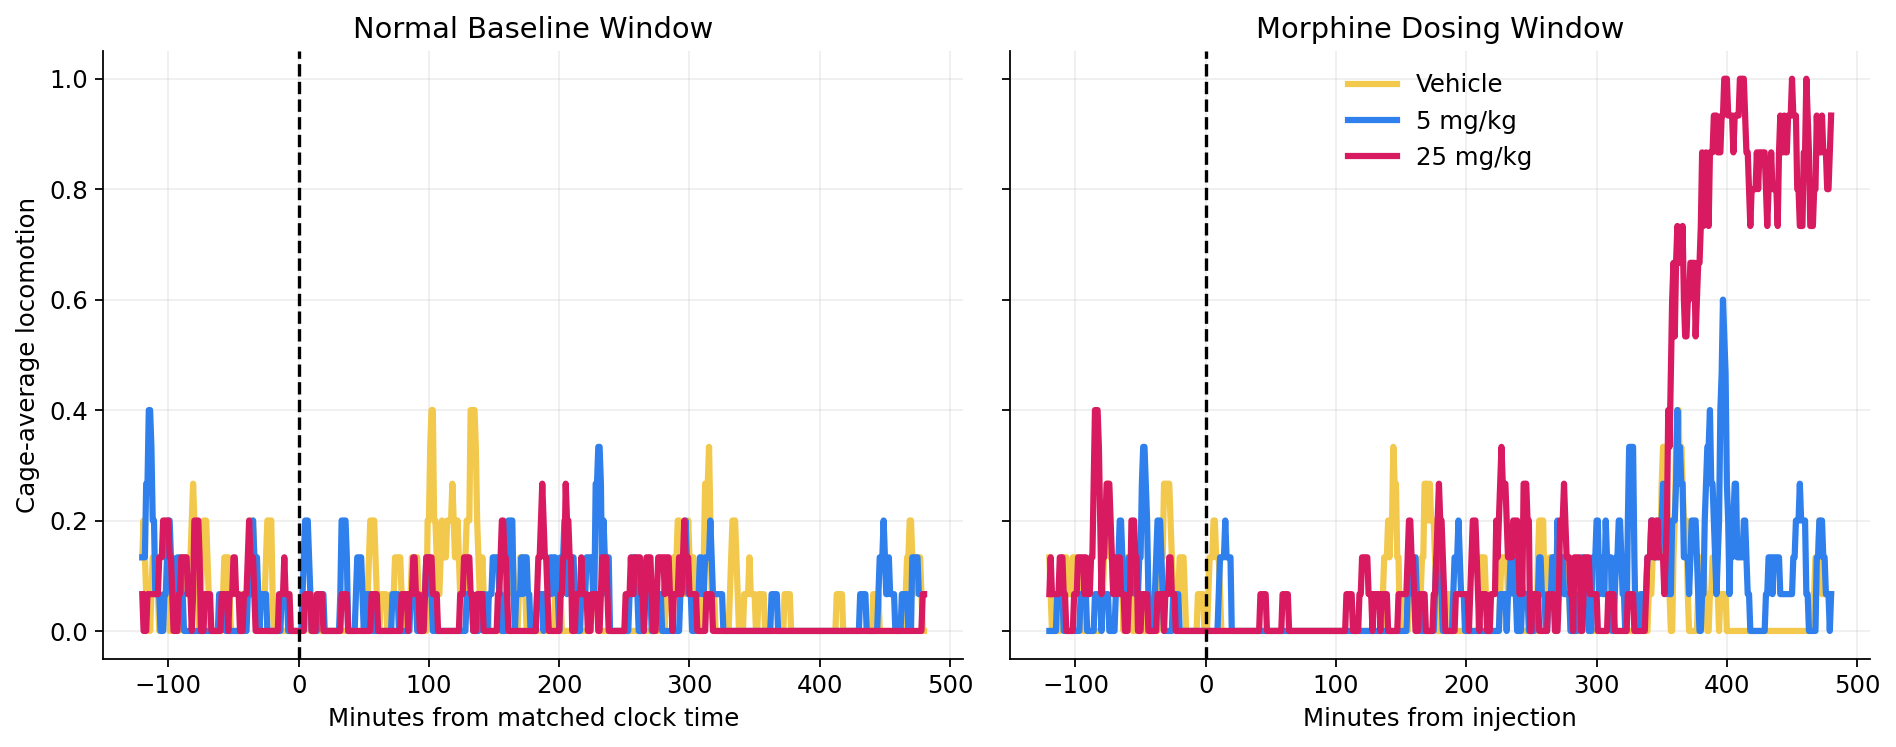

In [28]:
# =============================================================================
# Poster figure using locomotion bouts -> minute locomotion intensity
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOT_REP = "Rep1"
USE_DOSE = "dose_1"

REP_CAGES = {
    "vehicle": GROUPS["vehicle"][PLOT_REP]["cages"][0],
    "dose5": GROUPS["dose5"][PLOT_REP]["cages"][0],
    "dose25": GROUPS["dose25"][PLOT_REP]["cages"][0],
}

WINDOW_PRE = 120
WINDOW_POST = 480

SMOOTH_MIN = 5

GROUP_COLORS = {
    "vehicle": "#f2c94c",
    "dose5": "#2f80ed",
    "dose25": "#d81b60",
}

GROUP_LABELS = {
    "vehicle": "Vehicle",
    "dose5": "5 mg/kg",
    "dose25": "25 mg/kg",
}

# ---------------------------------------------------------------------
# Convert bouts -> minute locomotion seconds
# ---------------------------------------------------------------------

def build_minute_locomotion(df_loco, cfg):

    start = pd.to_datetime(cfg["analysis_start"])
    end = pd.to_datetime(cfg["analysis_end"]) + pd.Timedelta(days=1)

    idx = pd.date_range(start, end, freq="min", inclusive="left")

    mice = sorted(df_loco["animal_id"].unique())

    per_mouse = []

    for aid in mice:

        sub = df_loco[df_loco["animal_id"] == aid]

        vec = np.zeros(len(idx))

        for _, r in sub.iterrows():

            s = max(r["start_time"], start)
            e = min(r["end_time"], end)

            s_bin = int((s - start).total_seconds() // 60)
            e_bin = int((e - start).total_seconds() // 60)

            vec[s_bin:e_bin] += 1

        per_mouse.append(vec)

    per_mouse = np.vstack(per_mouse)

    cage_mean = per_mouse.mean(axis=0)

    s = pd.Series(cage_mean, index=idx)

    if SMOOTH_MIN:
        s = s.rolling(SMOOTH_MIN, center=True, min_periods=1).mean()

    return s


def extract_window(series, center, pre=120, post=480):

    idx = pd.date_range(
        center - pd.Timedelta(minutes=pre),
        center + pd.Timedelta(minutes=post),
        freq="min"
    )

    out = series.reindex(idx)

    out.index = np.arange(-pre, post + 1)

    return out


# ---------------------------------------------------------------------
# Timing
# ---------------------------------------------------------------------

cfg_ref = GROUPS["vehicle"][PLOT_REP]

dose_dt = cfg_ref[USE_DOSE]

baseline_day = int(np.mean(cfg_ref["baseline_days"]))

baseline_date = pd.to_datetime(cfg_ref["analysis_start"]) + pd.Timedelta(days=baseline_day - 1)

baseline_center = pd.Timestamp.combine(baseline_date.date(), dose_dt.time())

print("Dose time:", dose_dt)
print("Baseline center:", baseline_center)

# ---------------------------------------------------------------------
# Build traces
# ---------------------------------------------------------------------

baseline_traces = {}
drug_traces = {}

for group, cage in REP_CAGES.items():

    cfg = GROUPS[group][PLOT_REP]

    df = load_parquet_s3(
        conn,
        cage,
        cfg["analysis_start"],
        cfg["analysis_end"],
        "animal_bouts.parquet",
        columns=["animal_id","start_time","end_time","state_name"],
        where="state_name = 'animal_bouts.locomotion'"
    )

    df["start_time"] = pd.to_datetime(df["start_time"])
    df["end_time"] = pd.to_datetime(df["end_time"])

    cage_series = build_minute_locomotion(df, cfg)

    baseline_traces[group] = extract_window(cage_series, baseline_center, WINDOW_PRE, WINDOW_POST)

    drug_traces[group] = extract_window(cage_series, dose_dt, WINDOW_PRE, WINDOW_POST)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, axes = plt.subplots(1,2,figsize=(12,4.8),sharey=True)

# Baseline
ax = axes[0]

for g in ["vehicle","dose5","dose25"]:

    ax.plot(
        baseline_traces[g].index,
        baseline_traces[g].values,
        color=GROUP_COLORS[g],
        linewidth=2.8,
        label=GROUP_LABELS[g]
    )

ax.axvline(0,color="black",linestyle="--")

ax.set_title("Normal Baseline Window")
ax.set_xlabel("Minutes from matched clock time")
ax.set_ylabel("Cage-average locomotion")
ax.grid(alpha=0.2)

# Drug
ax = axes[1]

for g in ["vehicle","dose5","dose25"]:

    ax.plot(
        drug_traces[g].index,
        drug_traces[g].values,
        color=GROUP_COLORS[g],
        linewidth=2.8,
        label=GROUP_LABELS[g]
    )

ax.axvline(0,color="black",linestyle="--")

ax.set_title("Morphine Dosing Window")
ax.set_xlabel("Minutes from injection")
ax.grid(alpha=0.2)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

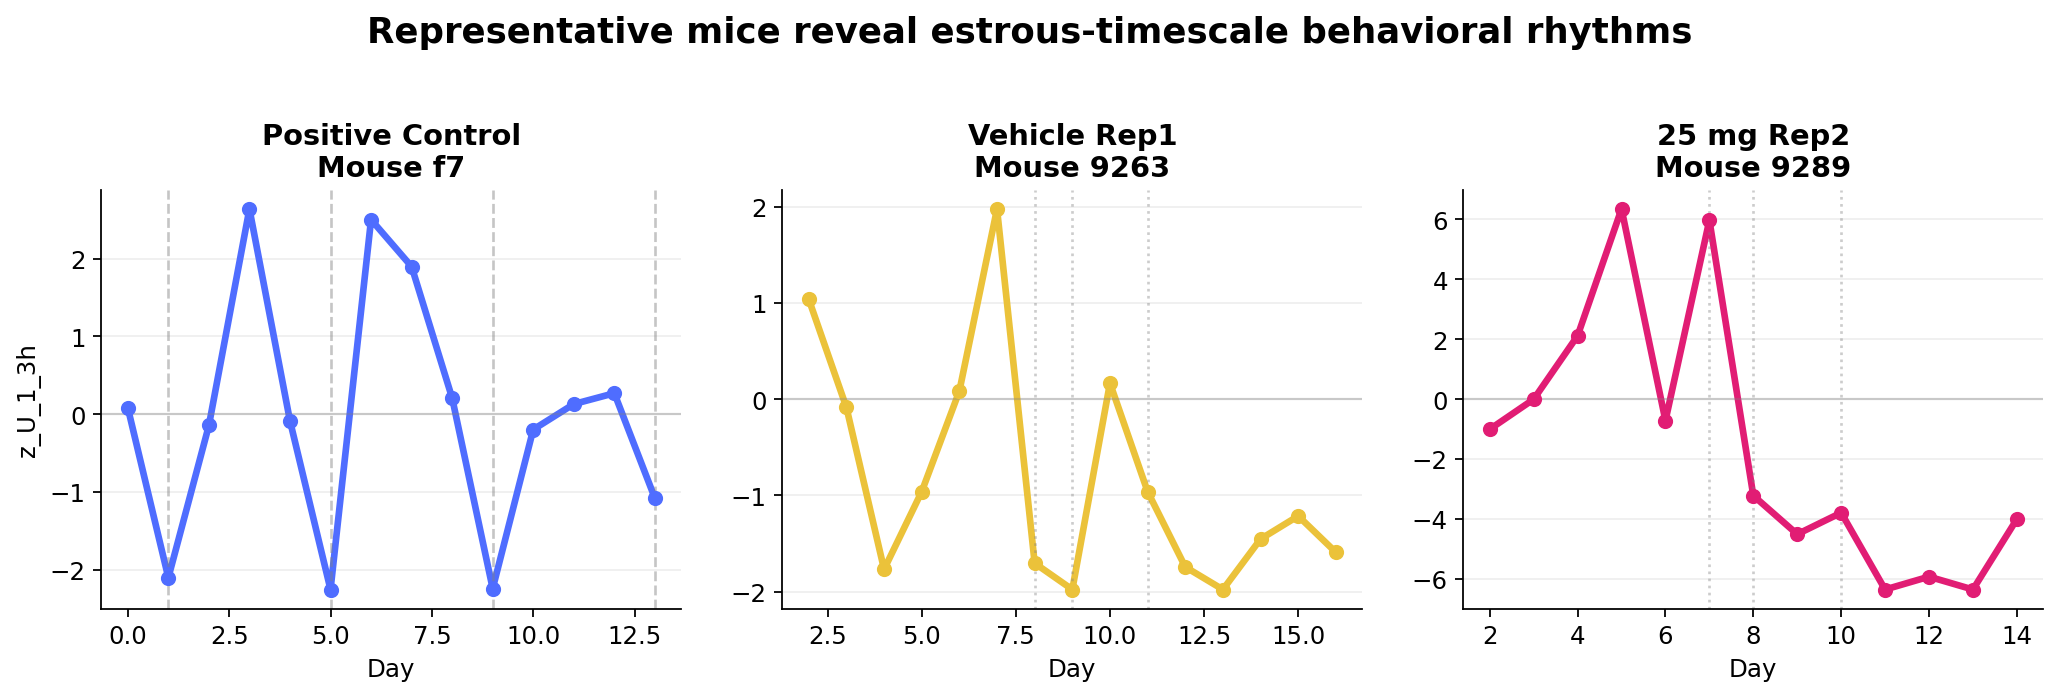

In [30]:
# =============================================================================
# Representative-mouse estrous figure
# Positive control vs Vehicle Rep1 vs 25 mg Rep2
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Choose representative mice
# ---------------------------------------------------------------------
# Vehicle mouse chosen from your results
VEHICLE_MOUSE = 9263

# Replace these with the exact mice you want
POSITIVE_MOUSE = "f7"   # e.g. "f7" or 7 depending on your positive-control mouse_id format
DOSE25_MOUSE   = 9289   # choose a disrupted-looking dose25 Rep2 mouse after inspection

# ---------------------------------------------------------------------
# Colors from your legend
# ---------------------------------------------------------------------
COLORS = {
    "positive": "#BFC8FF",   # light blue for positive control panel lines
    "vehicle":  "#EBC23A",   # yellow
    "dose25":   "#E11D74",   # magenta
}

BOLD_COLORS = {
    "positive": "#4F6DFF",   # darker blue mean line
    "vehicle":  "#EBC23A",   # yellow
    "dose25":   "#E11D74",   # magenta
}

# ---------------------------------------------------------------------
# Positive-control data source:
# dfp should already exist from your positive-control notebook
# columns: mouse_id, day, z_U_1_3h
#
# Morph2Rep data source:
# feat_qc should already exist from your Morph2Rep notebook
# columns: group, replicate, animal_id, day, z_U_1_3h
# ---------------------------------------------------------------------

def get_positive_mouse_df(dfp, mouse_id):
    sub = dfp[dfp["mouse_id"] == mouse_id].copy().sort_values("day")
    if sub.empty:
        raise ValueError(f"Positive-control mouse {mouse_id} not found in dfp['mouse_id'].")
    return sub

def get_morph_mouse_df(feat_qc, group, replicate, animal_id):
    sub = feat_qc[
        (feat_qc["group"] == group) &
        (feat_qc["replicate"] == replicate) &
        (feat_qc["animal_id"] == animal_id)
    ].copy().sort_values("day")
    if sub.empty:
        raise ValueError(f"Mouse {animal_id} not found for {group} {replicate}.")
    return sub

# ---------------------------------------------------------------------
# Optional helper to inspect candidate 25 mg Rep2 mice before plotting
# ---------------------------------------------------------------------
def preview_dose25_rep2_candidates(feat_qc, candidate_ids=None, ncols=3):
    sub = feat_qc[(feat_qc["group"] == "dose25") & (feat_qc["replicate"] == "Rep2")].copy()
    ids = sorted(sub["animal_id"].unique()) if candidate_ids is None else candidate_ids

    n = len(ids)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.8*nrows), sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, aid in zip(axes, ids):
        g = sub[sub["animal_id"] == aid].sort_values("day")
        ax.plot(g["day"], g["z_U_1_3h"], color=COLORS["dose25"], lw=2)
        ax.scatter(g["day"], g["z_U_1_3h"], color=COLORS["dose25"], s=22)
        ax.axhline(0, color="gray", lw=1, alpha=0.4)
        ax.set_title(f"Mouse {aid}")
        ax.set_xlabel("Day")
        ax.grid(True, axis="y", alpha=0.2)

    for ax in axes[n:]:
        ax.axis("off")

    axes[0].set_ylabel("z_U_1_3h")
    fig.suptitle("Dose25 Rep2 candidate mice", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Main plotting function
# ---------------------------------------------------------------------
def plot_representative_mice(dfp, feat_qc, positive_mouse, vehicle_mouse, dose25_mouse):
    if positive_mouse is None:
        raise ValueError("Set POSITIVE_MOUSE first.")
    if dose25_mouse is None:
        raise ValueError("Set DOSE25_MOUSE first.")

    pc = get_positive_mouse_df(dfp, positive_mouse)
    veh = get_morph_mouse_df(feat_qc, "vehicle", "Rep1", vehicle_mouse)
    d25 = get_morph_mouse_df(feat_qc, "dose25", "Rep2", dose25_mouse)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=False)

    # ---------------- Positive control ----------------
    ax = axes[0]
    ax.plot(pc["day"], pc["z_U_1_3h"], color=BOLD_COLORS["positive"], lw=3)
    ax.scatter(pc["day"], pc["z_U_1_3h"], color=BOLD_COLORS["positive"], s=34, zorder=3)

    # Expected ~4-day structure guides
    for d in [1, 5, 9, 13]:
        if d in pc["day"].values:
            ax.axvline(d, color="gray", linestyle="--", lw=1.2, alpha=0.45)

    ax.axhline(0, color="gray", lw=1, alpha=0.35)
    ax.set_title(f"Positive Control\nMouse {positive_mouse}", fontweight="bold")
    ax.set_xlabel("Day")
    ax.set_ylabel("z_U_1_3h")
    ax.grid(True, axis="y", alpha=0.2)

    # ---------------- Vehicle Rep1 ----------------
    ax = axes[1]
    ax.plot(veh["day"], veh["z_U_1_3h"], color=BOLD_COLORS["vehicle"], lw=3)
    ax.scatter(veh["day"], veh["z_U_1_3h"], color=BOLD_COLORS["vehicle"], s=34, zorder=3)

    # Event day guides for Rep1: dose1=8, cage change=9, dose2=11
    for d in [8, 9, 11]:
        if d in veh["day"].values:
            ax.axvline(d, color="gray", linestyle=":", lw=1.2, alpha=0.4)

    ax.axhline(0, color="gray", lw=1, alpha=0.35)
    ax.set_title(f"Vehicle Rep1\nMouse {vehicle_mouse}", fontweight="bold")
    ax.set_xlabel("Day")
    ax.grid(True, axis="y", alpha=0.2)

    # ---------------- 25 mg Rep2 ----------------
    ax = axes[2]
    ax.plot(d25["day"], d25["z_U_1_3h"], color=BOLD_COLORS["dose25"], lw=3)
    ax.scatter(d25["day"], d25["z_U_1_3h"], color=BOLD_COLORS["dose25"], s=34, zorder=3)

    # Event day guides for Rep2: dose1=7, cage change=8, dose2=10
    for d in [7, 8, 10]:
        if d in d25["day"].values:
            ax.axvline(d, color="gray", linestyle=":", lw=1.2, alpha=0.4)

    ax.axhline(0, color="gray", lw=1, alpha=0.35)
    ax.set_title(f"25 mg Rep2\nMouse {dose25_mouse}", fontweight="bold")
    ax.set_xlabel("Day")
    ax.grid(True, axis="y", alpha=0.2)

    fig.suptitle(
        "Representative mice reveal estrous-timescale behavioral rhythms",
        fontsize=16,
        fontweight="bold",
        y=1.03
    )
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Optional: inspect dose25 Rep2 candidates first
# ---------------------------------------------------------------------
# preview_dose25_rep2_candidates(feat_qc)

# ---------------------------------------------------------------------
# Final plot
# ---------------------------------------------------------------------
plot_representative_mice(
    dfp=dfp,
    feat_qc=feat_qc,
    positive_mouse=POSITIVE_MOUSE,
    vehicle_mouse=VEHICLE_MOUSE,
    dose25_mouse=DOSE25_MOUSE,
)

## 8. Optional save cells
Run these after whichever figure you decide is clearest.

In [ ]:
# Example saves:
# plt.savefig("poster_heatmap_p_state.png", bbox_inches="tight", dpi=300)
# plt.savefig("poster_heatmap_z_signal.png", bbox_inches="tight", dpi=300)
# plt.savefig("poster_lineplot_z_signal.png", bbox_inches="tight", dpi=300)
# plt.savefig("poster_lineplot_p_state.png", bbox_inches="tight", dpi=300)